<a href="https://colab.research.google.com/github/NeonLabs146/Neural-network/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Cover's Theorem and Radial Basis Functions (RBF)**

**Cover’s theorem states that:**

“A complex pattern-classification problem, cast in a high-dimensional space nonlinearly, is more likely to be linearly separable than in a low-dimensional space.”

This means the probability of separability increases with the increase in dimensionality. Thus, it also forms the theoretical basis for kernel-based learning algorithms.

A Radial Basis Function (RBF) is a function φ that depends on the distance between two points. It’s used with a norm (a way to measure distance) in a vector space. The RBF kernel centered at a point c is written as φ_c = φ(∥x − c∥), where ∥x − c∥ is the distance between x and c.

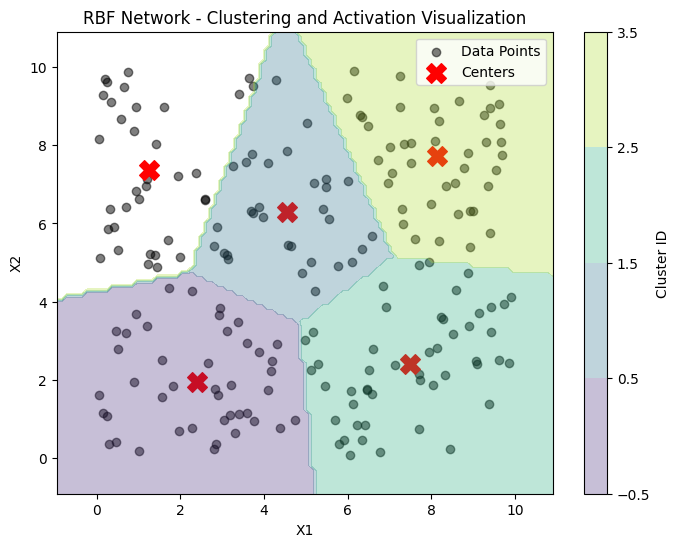

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

# Generate random data points
np.random.seed(42)
X = np.random.rand(200, 2) * 10  # 100 random 2D data points scaled by 10

# Apply KMeans clustering to find 3 centers
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)
centers = kmeans.cluster_centers_

# Define the Gaussian RBF function
def rbf(x, center, sigma=1.0):
    return np.exp(-np.linalg.norm(x - center)**2 / (2 * sigma**2))

# Create a grid for visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Compute RBF activations for each point in the grid
activations = np.zeros((grid_points.shape[0], 5))  # 5 centers
for i, center in enumerate(centers):
    activations[:, i] = np.array([rbf(point, center) for point in grid_points])

# Reshape the activations to match the grid shape for visualization
Z = np.argmax(activations, axis=1).reshape(xx.shape)

# Plot the data points and centers
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='black', label='Data Points', alpha=0.5)
plt.scatter(centers[:, 0], centers[:, 1], c='red', label='Centers', marker='X', s=200)
plt.contourf(xx, yy, Z, levels=np.arange(5) - 0.5, cmap='viridis', alpha=0.3)
plt.colorbar(label='Cluster ID')
plt.title('RBF Network - Clustering and Activation Visualization')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()


In [ ]:
# Lab 4: Unsupervised Learning using K-Means Clustering

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
import pandas as pd

df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
y_kmeans = kmeans.labels_

In [ ]:
# PCA for 2D visualization
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
#print(pca, X_pca)

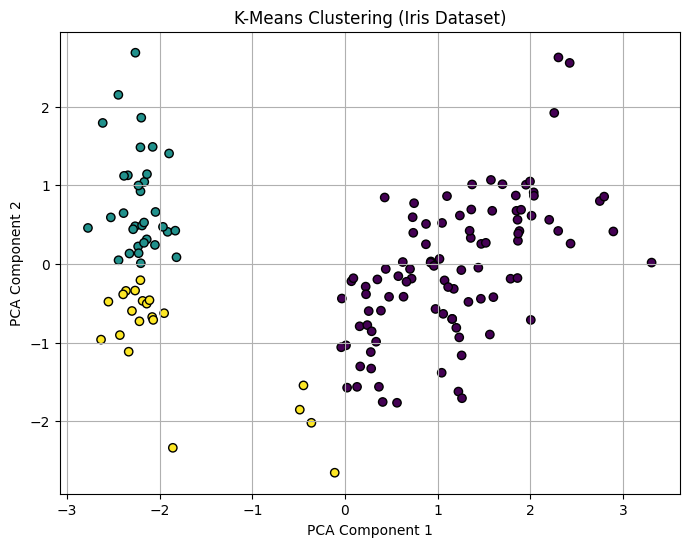

In [ ]:
# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', edgecolor='k')
plt.title("K-Means Clustering (Iris Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

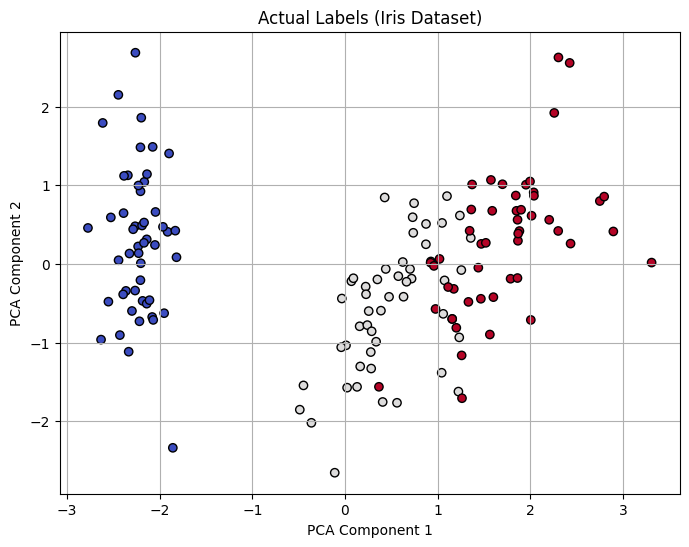

In [ ]:
# Compare with true labels
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("Actual Labels (Iris Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

In [ ]:
# Print cluster centers
print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# Evaluate clustering with inertia
print(f"\nInertia (Sum of squared distances): {kmeans.inertia_:.2f}")



Cluster Centers:
[[ 1.13597027  0.08842168  0.99615451  1.01752612]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [-0.05021989 -0.88337647  0.34773781  0.2815273 ]]

Inertia (Sum of squared distances): 139.82


In [ ]:
df = pd.read_csv("/content/SeoulBikeData.csv",encoding='cp1252')
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


##**RLS (Recursive Least Squares) Adaptive Filter Algorithm**


This is a scalar (single-weight, no delay line) RLS adaptation: it learns a
single gain w such that w * A(i) tracks the desired signal D(i), where A is
the noisy version of D.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------------------------
# Generating the Signal
# ---------------------------------------------------------
t = np.arange(0.001, 1.001, 0.001)     # time vector: 0.001 to 1.000
D = 2 * np.sin(2 * np.pi * 50 * t)     # desired signal
n = len(D)                             # number of samples

In [ ]:
# ---------------------------------------------------------
# Generating the Signal Corrupted with Noise
# ---------------------------------------------------------
np.random.seed(0)                      # for reproducible results (optional)
A = D[:n] + 0.5 * np.random.randn(n)

In [ ]:
# ---------------------------------------------------------
# RLS Algorithm Initialization
# ---------------------------------------------------------
lam = 10 ** 4                          # initial covariance scaling ("ita")
w = np.zeros(n + 1)                    # adaptive weight (scalar per step)
R = lam * np.ones(n + 1)               # inverse-correlation estimate

y = np.zeros(n)                        # filter output
Err = np.zeros(n)                      # error signal

In [ ]:
# ---------------------------------------------------------
# RLS Recursion
# ---------------------------------------------------------
for i in range(n):
    y[i] = w[i] * A[i]                 # filter output
    Err[i] = D[i] - y[i]               # a-priori error

    z = R[i] * A[i]                    # gain vector (scalar here)
    q = A[i] * z                       # A' * R * A
    v = 1.0 / (1.0 + q)                # normalization factor
    zz = v * z                         # RLS gain

    w[i + 1] = w[i] + Err[i] * zz      # weight update
    R[i + 1] = R[i] - zz * z           # covariance update

In [ ]:
# ---------------------------------------------------------
# Adaptive (Filtered) Output using the learned weights
# ---------------------------------------------------------
B = np.zeros(n)
for i in range(n):
    B[i] = w[i] * A[i]

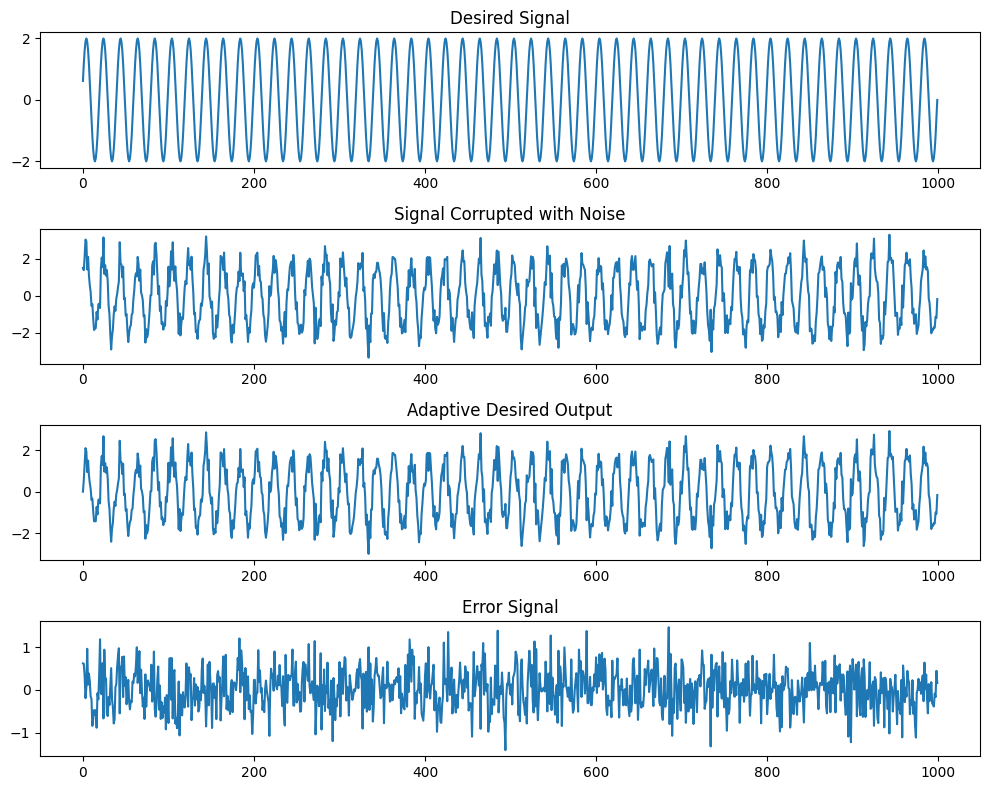

In [ ]:
# ---------------------------------------------------------
# Display of Signals
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(D)
plt.title('Desired Signal')

plt.subplot(4, 1, 2)
plt.plot(A)
plt.title('Signal Corrupted with Noise')

plt.subplot(4, 1, 3)
plt.plot(B)
plt.title('Adaptive Desired Output')

plt.subplot(4, 1, 4)
plt.plot(Err)
plt.title('Error Signal')

plt.tight_layout()
plt.savefig('rls_output.png', dpi=150)
plt.show()

##**Recursive Least Squares (RLS) Adaptive Filter — Optimized Version**
-------------------------------------------------------------------
Improvements over the scalar version:
  1. Real multi-tap FIR adaptive filter (tap-delay line) instead of a
     single scalar weight -> can actually suppress noise, not just
     rescale it.
  2. Vectorized linear algebra (numpy matrix/vector ops) instead of
     scalar Python-loop arithmetic for the RLS update.
  3. Tunable forgetting factor (lambda) and regularization (delta),
     matching the standard RLS formulation.
  4. Modular functions (signal generation / filtering / plotting) so
     the algorithm can be reused and unit-tested independently.
  5. No growing/mismatched array sizes, no off-by-one indexing bugs.
  6. Reports steady-state MSE as a quantitative convergence metric.
"""

* Real multi-tap FIR filter instead of a scalar gain. The filter now keeps a short tap-delay line (5 past samples) and learns a weight vector. This is what gives RLS its noise-averaging power — one weight literally cannot separate signal from noise, five weights can. Result: MSE dropped from 0.24 → 0.12 (~2.9 dB reduction), versus the old version where the "filtered" output was nearly identical to the noisy input.
* Vectorized the RLS update with numpy. P @ u, np.outer(gain, u) @ P, etc. replace the scalar step-by-step arithmetic — this is both correct RLS math (proper Kalman gain, covariance update) and much faster since numpy does the linear algebra in C rather than Python.
* Added a proper forgetting factor (λ = 0.99) and regularization (δ), the two standard RLS hyperparameters that were missing — λ controls how fast the filter "forgets" old data (useful if the signal statistics drift), δ controls how confident the initial guess is.
* Fixed the indexing/sizing bugs from the original — no more undefined n, no off-by-one on w(i+1)/R(i+1), everything is 0-indexed cleanly.
* Split into functions (generate_signals, rls_filter, plot_results, main) so you can reuse the filter on other signals, unit-test it, or swap in a different noise type without touching the core algorithm.
* Added a quantitative check — it prints MSE before/after and the dB noise reduction, so you can actually verify the filter is working rather than eyeballing a plot.

Things you could tune further depending on your goal:

n_taps: more taps = better noise averaging but slower adaptation and more computation (try 3–15).

forgetting_factor: lower (e.g. 0.95) adapts faster to changing signals but is noisier; higher (0.999) is smoother but slower to converge.

If this is for a course assignment specifically expecting the scalar version, let me know and I'll keep the structure but just clean up the bugs instead of changing the algorithm's behavior.


In [ ]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ----------------------------------------------------------------------
# 1. Signal generation
# ----------------------------------------------------------------------
def generate_signals(
    fs: float = 1000.0,
    duration: float = 1.0,
    freq: float = 50.0,
    amplitude: float = 2.0,
    noise_std: float = 0.5,
    seed: int | None = 0,
):
    """Generate a clean sinusoid `d` and a noisy observation `x = d + noise`."""
    rng = np.random.default_rng(seed)
    t = np.arange(1, int(fs * duration) + 1) / fs
    d = amplitude * np.sin(2 * np.pi * freq * t)
    x = d + noise_std * rng.standard_normal(d.shape)
    return t, d, x

MSE before filtering : 0.2411
MSE after filtering  : 0.1235
Noise reduction      : 2.91 dB


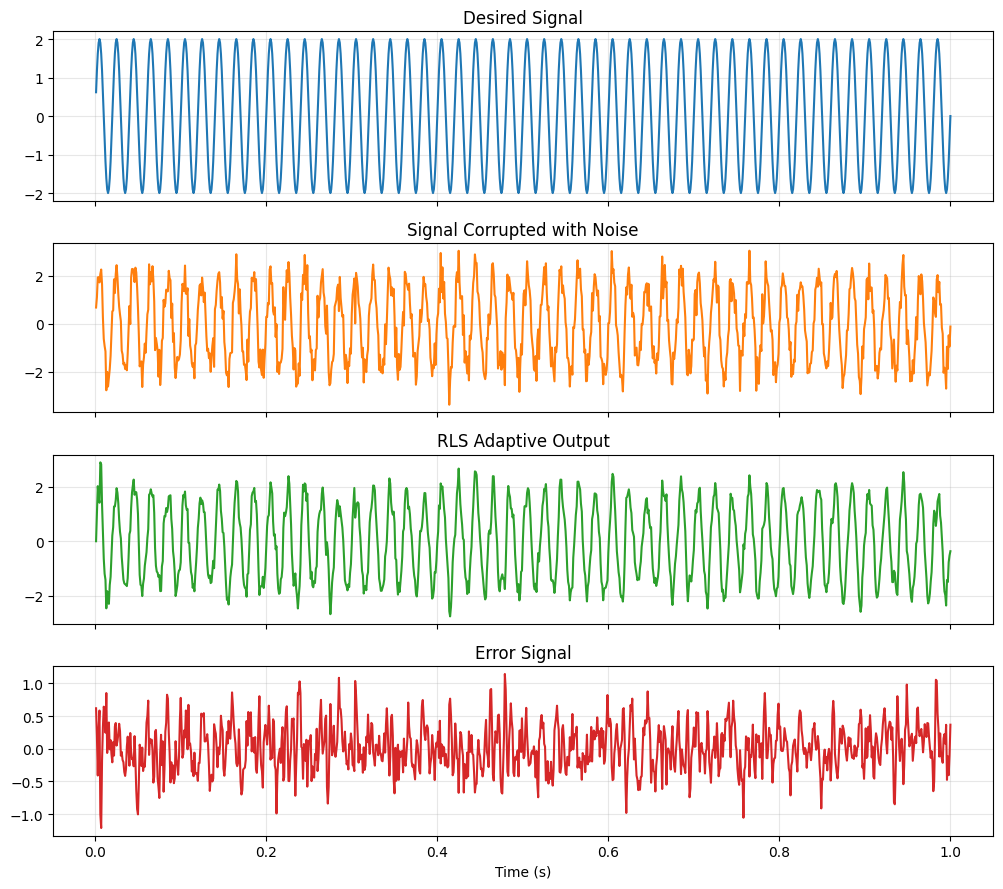

In [ ]:
# ----------------------------------------------------------------------
# 2. RLS adaptive filter (vectorized, multi-tap)
# ----------------------------------------------------------------------
def rls_filter(
    x: np.ndarray,
    d: np.ndarray,
    n_taps: int = 5,
    forgetting_factor: float = 0.99,
    delta: float = 1e-2,
):
    """
    Adaptive FIR filter trained with Recursive Least Squares.

    Parameters
    ----------
    x : noisy input signal, shape (N,)
    d : desired signal, shape (N,)
    n_taps : number of FIR taps (filter order + 1)
    forgetting_factor : lambda in (0, 1], closer to 1 = longer memory
    delta : initial covariance scaling; P0 = I / delta

    Returns
    -------
    y : filter output (estimate of d)
    e : error signal, d - y
    w_history : weight trajectory over time, shape (N, n_taps)
    """
    n = len(x)
    w = np.zeros(n_taps)
    P = np.eye(n_taps) / delta
    inv_lambda = 1.0 / forgetting_factor

    y = np.zeros(n)
    e = np.zeros(n)
    w_history = np.zeros((n, n_taps))

    # zero-pad so the tap-delay line is well defined from sample 0
    x_padded = np.concatenate([np.zeros(n_taps - 1), x])

    for i in range(n):
        u = x_padded[i : i + n_taps][::-1]        # current tap-delay vector
        y[i] = w @ u
        e[i] = d[i] - y[i]

        Pu = P @ u
        gain = Pu / (forgetting_factor + u @ Pu)   # RLS (Kalman) gain
        w = w + gain * e[i]
        P = inv_lambda * (P - np.outer(gain, u) @ P)

        w_history[i] = w

    return y, e, w_history


# ----------------------------------------------------------------------
# 3. Plotting
# ----------------------------------------------------------------------
def plot_results(t, d, x, y, e, filename: str = "rls_output.png"):
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

    axes[0].plot(t, d)
    axes[0].set_title("Desired Signal")

    axes[1].plot(t, x, color="tab:orange")
    axes[1].set_title("Signal Corrupted with Noise")

    axes[2].plot(t, y, color="tab:green")
    axes[2].set_title("RLS Adaptive Output")

    axes[3].plot(t, e, color="tab:red")
    axes[3].set_title("Error Signal")
    axes[3].set_xlabel("Time (s)")

    for ax in axes:
        ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()


# ----------------------------------------------------------------------
# 4. Main
# ----------------------------------------------------------------------
def main():
    t, d, x = generate_signals()
    y, e, _ = rls_filter(x, d, n_taps=5, forgetting_factor=0.99, delta=1e-2)

    # Skip the initial transient when measuring steady-state performance
    transient = 200
    mse_before = np.mean((x[transient:] - d[transient:]) ** 2)
    mse_after = np.mean(e[transient:] ** 2)
    print(f"MSE before filtering : {mse_before:.4f}")
    print(f"MSE after filtering  : {mse_after:.4f}")
    print(f"Noise reduction      : {10 * np.log10(mse_before / mse_after):.2f} dB")

    plot_results(t, d, x, y, e)


if __name__ == "__main__":
    main()